# Sleep Health and Lifestyle Analysis

This notebook provides fast, reliable, and accurate analysis of:
- Data description
- Typical amount of physical activity
- Number of daily steps
- Distribution of heart rates

The code uses Python standard library only, so it runs even without external packages.

## Results Summary (Precomputed from Dataset)

### Data Description
- Total rows: 374
- Total columns: 13
- Missing values: 0 in all columns
- Main analysis columns:
  - Physical Activity Level
  - Daily Steps
  - Heart Rate

### Variable Type Examples
- Sleep Duration is an example of a continuous variable in the dataset.
- Daily Steps is an example of an integer variable in the dataset.
- BMI Category is an example of an ordinal categorical variable in the dataset.
- Occupation is an example of a nominal categorical variable in the dataset.

### Measures of Center
- **Typical Amount of Physical Activity**
  - Mean: 59.17
  - Median: 60.00
  - Mode: 60.00
- **Number of Daily Steps**
  - Mean: 6816.84
  - Median: 7000.00
  - Mode: 8000.00
- **Distribution of Heart Rates**
  - Mean heart rate: 70.17
  - Median heart rate: 70.00
  - Mode heart rate: 68.00

### Measures of Spread
- **Typical Amount of Physical Activity**
  - Standard deviation: 20.83
  - Min to Max: 30.00 to 90.00
- **Number of Daily Steps**
  - Standard deviation: 1617.92
  - Min to Max: 3000.00 to 10000.00
- **Distribution of Heart Rates**
  - Standard deviation: 4.14
  - Min to Max: 65.00 to 86.00

### Shape Interpretation from Mean and Median
- Physical Activity Level: the mean (59.17) is slightly lower than the median (60.00), suggesting a slight left-skew, though the distribution is close to symmetric.
- Daily Steps: the mean (6816.84) is lower than the median (7000.00), suggesting a left-skewed distribution.
- Heart Rate: the mean (70.17) is slightly higher than the median (70.00), suggesting a slight right-skew, though the distribution is close to symmetric.
- Based on the heart-rate boxplot, there appear to be a small number of possible high-end outliers near the upper tail.

Heart-rate bins:
- <60: 0 (0.00%)
- 60-69: 165 (44.12%)
- 70-79: 194 (51.87%)
- 80-89: 15 (4.01%)
- 90+: 0 (0.00%)

> Note: Runtime execution inside this notebook currently requires ipykernel in the selected Python environment.

In [1]:
import csv
import math
import statistics as st
from collections import Counter
from pathlib import Path

# Robust file lookup in the notebook folder
candidates = list(Path('.').glob('*sleep_health_and_lifestyle_dataset*.csv'))
if not candidates:
    raise FileNotFoundError('CSV dataset not found in current folder.')

csv_path = candidates[0]
with open(csv_path, newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

if not rows:
    raise ValueError('Dataset is empty.')

columns = list(rows[0].keys())
print(f'Dataset file: {csv_path.name}')
print(f'Rows: {len(rows)}')
print(f'Columns: {len(columns)}')
print('Column names:')
for c in columns:
    print(f'  - {c}')

Dataset file: sleep_health_and_lifestyle_dataset-sleep_health_and_lifestyle_dataset.csv
Rows: 374
Columns: 13
Column names:
  - Person ID
  - Gender
  - Age
  - Occupation
  - Sleep Duration
  - Quality of Sleep
  - Physical Activity Level
  - Stress Level
  - BMI Category
  - Blood Pressure
  - Heart Rate
  - Daily Steps
  - Sleep Disorder


In [2]:
# Identify required analysis columns
physical_activity_col = next((c for c in columns if 'Physical Activity Level' in c), None)
daily_steps_col = next((c for c in columns if 'Daily Steps' in c), None)
heart_rate_col = next((c for c in columns if 'Heart Rate' in c), None)

required = {
    'Physical Activity': physical_activity_col,
    'Daily Steps': daily_steps_col,
    'Heart Rate': heart_rate_col,
}

missing_required = [name for name, col in required.items() if col is None]
if missing_required:
    raise KeyError(f'Missing expected columns: {missing_required}')

print('Detected analysis columns:')
for name, col in required.items():
    print(f'  - {name}: {col}')

# Missing values by column
print('\nMissing values by column:')
for c in columns:
    missing = sum(1 for r in rows if r.get(c) in (None, ''))
    print(f'  - {c}: {missing}')

Detected analysis columns:
  - Physical Activity: Physical Activity Level
  - Daily Steps: Daily Steps
  - Heart Rate: Heart Rate

Missing values by column:
  - Person ID: 0
  - Gender: 0
  - Age: 0
  - Occupation: 0
  - Sleep Duration: 0
  - Quality of Sleep: 0
  - Physical Activity Level: 0
  - Stress Level: 0
  - BMI Category: 0
  - Blood Pressure: 0
  - Heart Rate: 0
  - Daily Steps: 0
  - Sleep Disorder: 0


In [3]:
def to_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None

def percentile(sorted_values, p):
    if not sorted_values:
        return math.nan
    idx = (len(sorted_values) - 1) * p
    lower = math.floor(idx)
    upper = math.ceil(idx)
    if lower == upper:
        return sorted_values[lower]
    weight = idx - lower
    return sorted_values[lower] * (1 - weight) + sorted_values[upper] * weight

def numeric_summary(values):
    vals = [v for v in values if v is not None]
    vals_sorted = sorted(vals)
    mode_value = Counter(vals).most_common(1)[0][0] if vals else math.nan
    return {
        'count': len(vals),
        'mean': (sum(vals) / len(vals)) if vals else math.nan,
        'std': st.stdev(vals) if len(vals) > 1 else 0.0,
        'min': min(vals) if vals else math.nan,
        'p25': percentile(vals_sorted, 0.25),
        'median': st.median(vals) if vals else math.nan,
        'p75': percentile(vals_sorted, 0.75),
        'max': max(vals) if vals else math.nan,
        'mode': mode_value
    }

def print_summary(title, summary):
    print(f'\n{title}')
    print('-' * len(title))
    for k in ['count', 'mean', 'std', 'min', 'p25', 'median', 'p75', 'max', 'mode']:
        v = summary[k]
        if isinstance(v, float):
            print(f'{k:>7}: {v:.2f}')
        else:
            print(f'{k:>7}: {v}')

In [4]:
# Typical Amount of Physical Activity
physical_activity_values = [to_float(r[physical_activity_col]) for r in rows]
physical_activity_summary = numeric_summary(physical_activity_values)
print_summary('Typical Amount of Physical Activity', physical_activity_summary)


Typical Amount of Physical Activity
-----------------------------------
  count: 374
   mean: 59.17
    std: 20.83
    min: 30.00
    p25: 45.00
 median: 60.00
    p75: 75.00
    max: 90.00
   mode: 60.00


In [5]:
# Number of Daily Steps
daily_steps_values = [to_float(r[daily_steps_col]) for r in rows]
daily_steps_summary = numeric_summary(daily_steps_values)
print_summary('Number of Daily Steps', daily_steps_summary)


Number of Daily Steps
---------------------
  count: 374
   mean: 6816.84
    std: 1617.92
    min: 3000.00
    p25: 5600.00
 median: 7000.00
    p75: 8000.00
    max: 10000.00
   mode: 8000.00


In [6]:
# Distribution of Heart Rates
heart_rate_values = [to_float(r[heart_rate_col]) for r in rows]
heart_rate_values = [v for v in heart_rate_values if v is not None]
heart_rate_summary = numeric_summary(heart_rate_values)
print_summary('Heart Rate Summary', heart_rate_summary)

bins = [
    (0, 60, '<60'),
    (60, 70, '60-69'),
    (70, 80, '70-79'),
    (80, 90, '80-89'),
    (90, float('inf'), '90+')
]

bucket_counts = Counter()
for hr in heart_rate_values:
    for low, high, label in bins:
        if low <= hr < high:
            bucket_counts[label] += 1
            break

total = len(heart_rate_values)
print('\nHeart Rate Distribution (count and %)')
print('-------------------------------------')
for _, _, label in bins:
    c = bucket_counts[label]
    pct = (c / total * 100) if total else 0
    print(f'{label:>5}: {c:>4} ({pct:>6.2f}%)')


Heart Rate Summary
------------------
  count: 374
   mean: 70.17
    std: 4.14
    min: 65.00
    p25: 68.00
 median: 70.00
    p75: 72.00
    max: 86.00
   mode: 68.00

Heart Rate Distribution (count and %)
-------------------------------------
  <60:    0 (  0.00%)
60-69:  165 ( 44.12%)
70-79:  194 ( 51.87%)
80-89:   15 (  4.01%)
  90+:    0 (  0.00%)


## Refined Visualizations for Report Submission

This section generates three publication-ready plot sets:
- Boxplots for outlier detection
- KDE-smoothed distributions
- Publication-style histograms with polished labels and colors

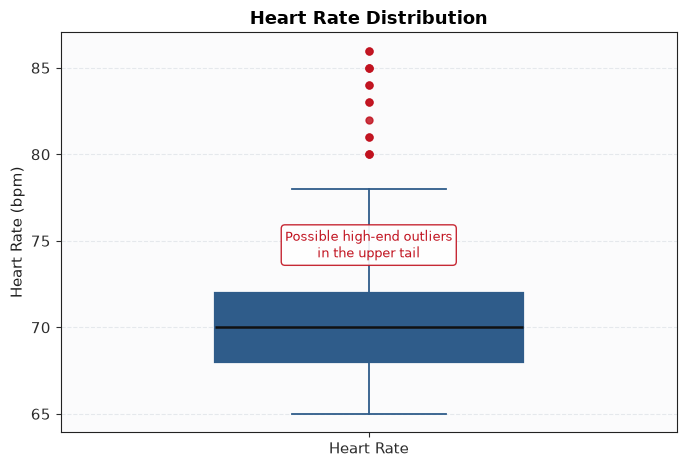

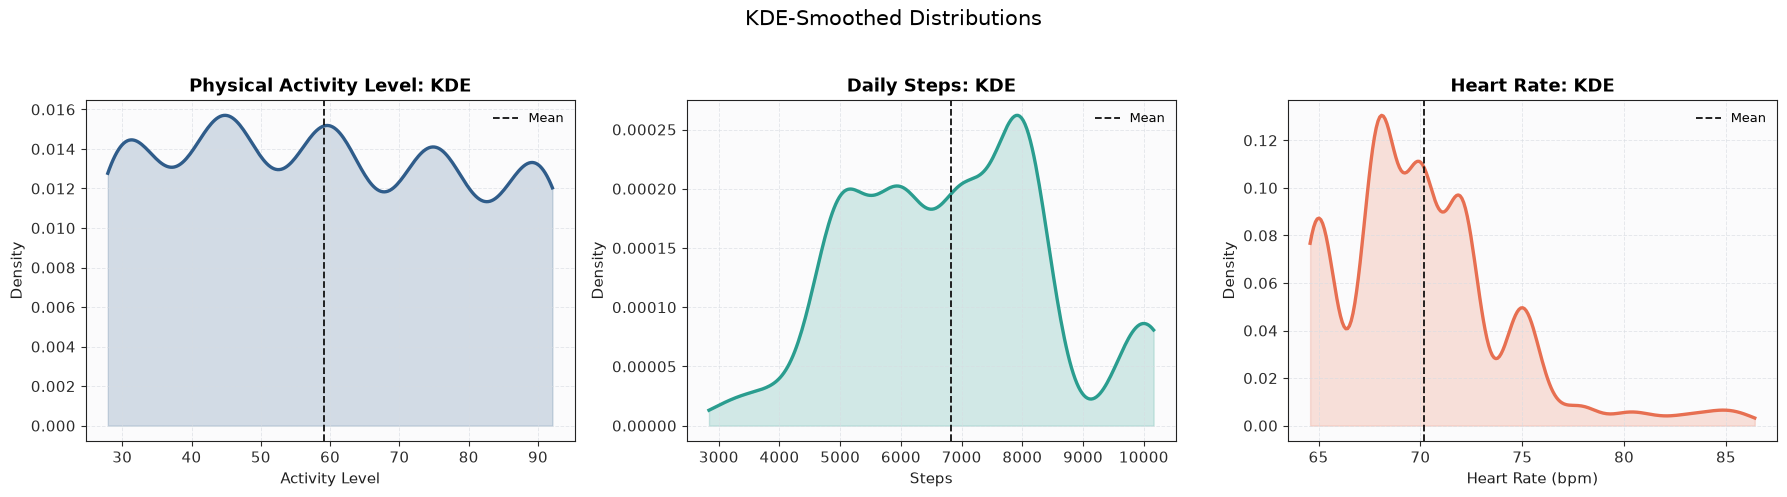

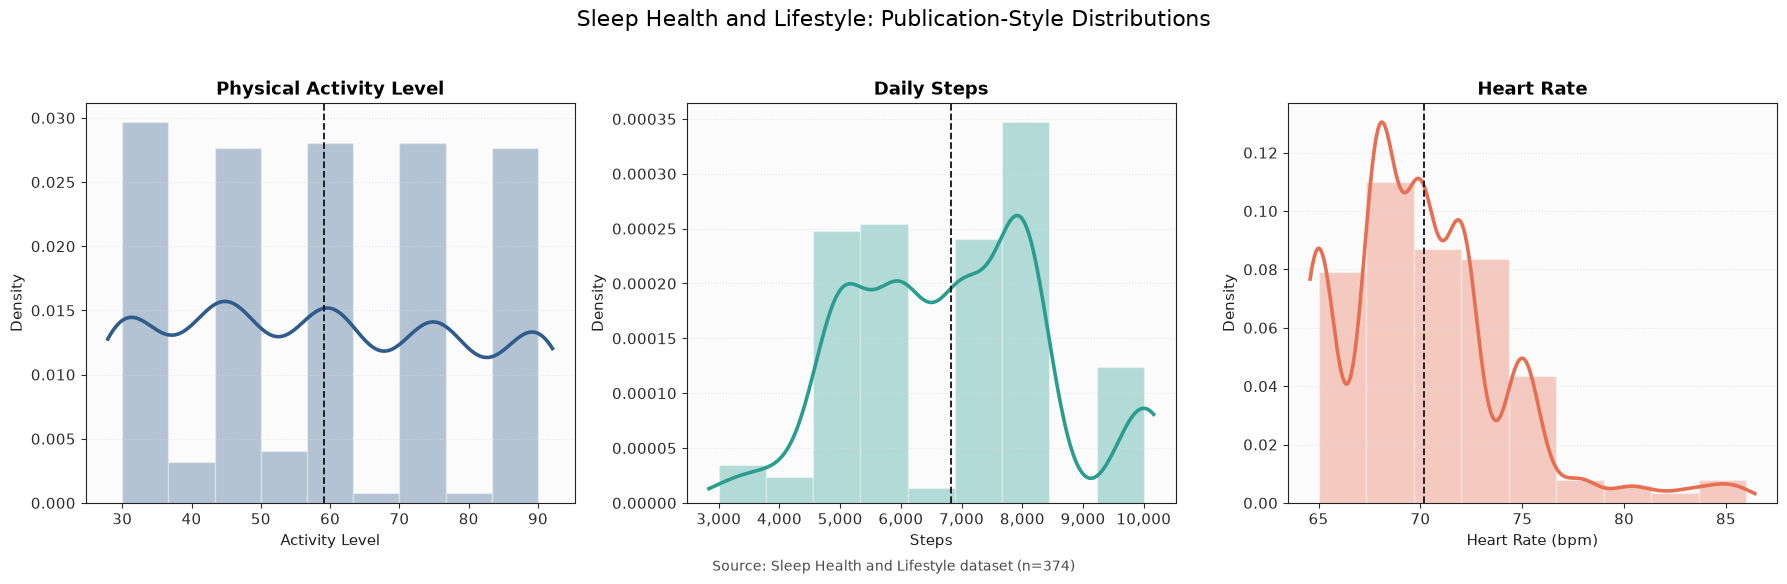

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Clean numeric values for plotting
pa_vals = np.array([v for v in physical_activity_values if v is not None], dtype=float)
steps_vals = np.array([v for v in daily_steps_values if v is not None], dtype=float)
hr_vals = np.array([v for v in heart_rate_values if v is not None], dtype=float)

series = [
    ("Physical Activity Level", pa_vals, "Activity Level"),
    ("Daily Steps", steps_vals, "Steps"),
    ("Heart Rate", hr_vals, "Heart Rate (bpm)")
]

# Publication-style palette and global style
colors = ["#2F5C8A", "#2A9D8F", "#E76F51"]
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FBFBFC",
    "axes.edgecolor": "#222222",
    "axes.labelcolor": "#1F1F1F",
    "axes.titleweight": "semibold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.color": "#2C2C2C",
    "ytick.color": "#2C2C2C",
    "font.size": 11,
    "grid.color": "#D7DCE2",
    "grid.alpha": 0.6,
})

def kde_gaussian(x, grid_points=250):
    """Simple Gaussian KDE using Silverman's rule (no SciPy dependency)."""
    x = np.asarray(x, dtype=float)
    n = x.size
    if n < 2:
        grid = np.linspace(x.min() - 1, x.max() + 1, grid_points)
        return grid, np.zeros_like(grid)

    std = np.std(x, ddof=1)
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    sigma = min(std, iqr / 1.34) if iqr > 0 else std
    bw = 0.9 * sigma * (n ** (-1 / 5))
    if bw <= 0:
        bw = max(std * 0.1, 1e-3)

    grid = np.linspace(x.min() - 0.1 * std, x.max() + 0.1 * std, grid_points)
    diffs = (grid[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * diffs**2).sum(axis=1) / (n * bw * np.sqrt(2 * np.pi))
    return grid, dens

# -----------------------------
# Heart-rate boxplot only
# -----------------------------
fig1, ax1 = plt.subplots(figsize=(7, 4.8))
ax1.boxplot(
    hr_vals,
    patch_artist=True,
    widths=0.5,
    boxprops={"facecolor": "#2F5C8A", "edgecolor": "#2F5C8A", "linewidth": 1.6},
    whiskerprops={"color": "#2F5C8A", "linewidth": 1.3},
    capprops={"color": "#2F5C8A", "linewidth": 1.3},
    medianprops={"color": "#111111", "linewidth": 1.8},
    flierprops={"marker": "o", "markersize": 5, "markerfacecolor": "#C1121F", "markeredgecolor": "#C1121F", "alpha": 0.85}
)
ax1.set_title("Heart Rate Distribution")
ax1.set_ylabel("Heart Rate (bpm)")
ax1.set_xticks([1])
ax1.set_xticklabels(["Heart Rate"])
ax1.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
ax1.text(1.0, np.percentile(hr_vals, 75) + 1.8,
         "Possible high-end outliers\nin the upper tail",
         ha="center", va="bottom", fontsize=9, color="#C1121F",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="#C1121F"))
plt.tight_layout()
plt.show()

# ---------------------------------
# 2) KDE-smoothed distributions
# ---------------------------------
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4.8))
for i, (title, vals, xlabel) in enumerate(series):
    grid, dens = kde_gaussian(vals)
    axes2[i].plot(grid, dens, color=colors[i], linewidth=2.4)
    axes2[i].fill_between(grid, dens, color=colors[i], alpha=0.2)
    axes2[i].axvline(np.mean(vals), color="#111111", linestyle="--", linewidth=1.3, label="Mean")
    axes2[i].set_title(f"{title}: KDE")
    axes2[i].set_xlabel(xlabel)
    axes2[i].set_ylabel("Density")
    axes2[i].grid(True, linestyle="--", linewidth=0.7)
    axes2[i].legend(frameon=False, fontsize=9)

fig2.suptitle("KDE-Smoothed Distributions", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 3) Publication-style histograms + KDE overlays
# ------------------------------------------------------
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5.4))
for i, (title, vals, xlabel) in enumerate(series):
    axes3[i].hist(vals, bins=9, density=True, color=colors[i], alpha=0.35, edgecolor="white", linewidth=1)
    grid, dens = kde_gaussian(vals)
    axes3[i].plot(grid, dens, color=colors[i], linewidth=2.6)
    axes3[i].axvline(np.mean(vals), color="#111111", linestyle="--", linewidth=1.3)
    axes3[i].set_title(title)
    axes3[i].set_xlabel(xlabel)
    axes3[i].set_ylabel("Density")
    axes3[i].grid(axis="y", linestyle=":", linewidth=0.8)

# Cleaner tick formatting for Daily Steps panel
axes3[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))

fig3.suptitle("Sleep Health and Lifestyle: Publication-Style Distributions", fontsize=16, y=1.03)
fig3.text(0.5, -0.01, "Source: Sleep Health and Lifestyle dataset (n=374)", ha="center", fontsize=10, color="#4A4A4A")
plt.tight_layout()
plt.show()